In [3]:
import os
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import random

# from data.charge.charge_dataset import ChargedParticleData
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

seed = 43
torch.manual_seed(seed)
torch.cuda.manual_seed(seed) # If using GPU
torch.cuda.manual_seed_all(seed) # If using multi-GPU
np.random.seed(seed)
random.seed(seed)

from train import test_step
from model import VanillaTransformer
from utils import *
from torchsummary import summary

usage: ipykernel_launcher.py [-h] [--data-path DATA_PATH] [--dataset DATASET]
                             [--n-charges N_CHARGES]
ipykernel_launcher.py: error: unrecognized arguments: -f /home/ommprakash.sahoo/.local/share/jupyter/runtime/kernel-125015ce-af46-4cfb-a40f-20cbb0c81ea2.json


SystemExit: 2

In [2]:
class ChargedParticleData(Dataset):
    def __init__(self, mode, directory, n_particles, name_format, scale_data=True, custom_range=True) -> None:
        super().__init__()
        self.mode = mode
        self.directory = directory
        self.n_particles = n_particles
        self.name_format = name_format
        self.scale_data = scale_data
        self.custom_range = custom_range

        (self.charge, self.location, self.velocity) = self.load_data()
        self.dataset = self.transform_data(self.charge, self.location, self.velocity) # shape: (sample, time, n_particles, 5)

    def load_data(self): 
        charge = np.load(os.path.join(self.directory, self.name_format.format(data='charges', mode=self.mode, n=self.n_particles))) # shape: (sample, n_particles, 1)
        location = np.load(os.path.join(self.directory, self.name_format.format(data='loc', mode=self.mode, n=self.n_particles))) # shape: (sample, time, 2, n_particles)
        velocity = np.load(os.path.join(self.directory, self.name_format.format(data='vel', mode=self.mode, n=self.n_particles))) # shape: (sample, time, 2, n_particles)

        charge = torch.from_numpy(charge) # shape: (sample, n_particles, 1)
        location = torch.from_numpy(location) # shape: (sample, time, 2, n_particles)
        velocity = torch.from_numpy(velocity) # shape: (sample, time, 2, n_particles)
        return charge, location, velocity

    def transform_data(self, charge, location, velocity):
        time = velocity.size(1)
        location_ = location.transpose(-1, -2) # shape: (sample, time, n_particles, 2)
        velocity_ = velocity.transpose(-1, -2) # shape: (sample, time, n_particles, 2)
        charge_ = charge.unsqueeze(1).repeat(1,time,1,1) # shape: (sample, time, n_particles, 1)
        
        data = torch.concat([charge_, location_, velocity_], dim=-1) # shape: (sample, time, n_particles, 5)
        self.n_features = data.size(-1)
        self.n_particles = data.size(-2)
        return data # shape: (sample, time, n_particles, 5)

    def __len__(self):
        return self.dataset.size(0)
    
    def __getitem__(self, index):
        data = self.dataset[index] # shape: (1, time, n_particles, 5)
        if self.scale_data:
            data_ = data.reshape(-1, data.size(-1))
            if self.custom_range:
                min_ = torch.tensor([-1, -5, -5, -7, -7])
                max_ = torch.tensor([1, 5, 5, 7, 7])
            else:
                min_ = data_.min(dim=0)[0]
                max_ = data_.max(dim=0)[0]
            data_ = (data_-min_)/(max_-min_)
            if torch.isnan(data_).any():
                print('nan value recieved in index', index)
            # print(data_.size(), data.size(), index)
            data_ = data_.view(data.size())
            # data_[:, :, 0] = data[:, :, 0]
            data = data_
        return {
            'data': data, # shape: (1, time, n_particles, 5)
            # 'location': self.location[index], # shape: (1, time, 2, n_particles)
            # 'velocity': self.velocity[index], # shape: (1, time, 2, n_particles)
            # 'charge': self.charge[index] # shape: (1, n_particles, 1)
        }    


In [3]:
config = load_config('config.yml')
train_opt = config.train
model_opt = vars(config.model).get('transformer')
data_opt = vars(config.data).get('charge')

In [4]:
name = 'charge'
name_format = '{data}_{mode}_charged{n}.npy'
n_particles = 5
encoder_ratio = 0.6
only_encoder = True
model_file = 'test_model.pt'
directory = os.path.join('data', name, f'charged{n_particles}')
test_data = ChargedParticleData('test', directory, n_particles, name_format)
test_dataloader = DataLoader(test_data, batch_size=1, shuffle=True)

In [5]:
n_features = test_data.dataset.size(-1)
model = VanillaTransformer(model_opt, n_features, n_particles).to(device)
optim = torch.optim.Adam(model.parameters(), lr=train_opt.lr)
state = torch.load(model_file)
init_epoch = state['epoch']+1
model.load_state_dict(state['model'])
optim.load_state_dict(state['optimizer'])
model_opt = state['model_opt']
train_opt = state['train_opt']

In [6]:
model

VanillaTransformer(
  (activation): ReLU()
  (enc_embedding): Embedding(5, 32)
  (enc_mlp): Sequential(
    (layer0): Linear(in_features=5, out_features=32, bias=True)
    (activation0): ReLU()
    (drop0): Dropout(p=0, inplace=False)
  )
  (encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-1): 2 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0, inplace=False)
        (dropout2): Dropout(p=0, inplace=False)
        (activation): ReLU()
      )
    )
  )
  (out_mlp): OUT_MLP(
    (activation): R

In [6]:
td = random.choice(list(test_dataloader))
data = td['data'].to(device).float()
time = data.size(1)
hf_time = int(time*encoder_ratio)

model.eval()
val_batch_loss = []
with torch.no_grad():
        test_in = data[:, :hf_time, :, :] # shape: (batch, s1, n_particles, n_features)
        test_label = data[:, hf_time:, :, :] # shape: (batch, s2, n_particles, n_features)
        n_time_steps = data.size(1)-hf_time
        out = test_step(model, only_encoder, test_in, n_time_steps, train_opt, model_opt, device)    
                      

/home/ommprakash.sahoo/miniconda3/envs/agent/lib/python3.9/site-packages/torch/nn/modules/transformer.py:562: UserWarning: Converting mask without torch.bool dtype to bool; this will negatively affect performance. Prefer to use a boolean mask directly. (Triggered internally at /opt/conda/conda-bld/pytorch_1682343964576/work/aten/src/ATen/native/transformers/attention.cpp:150.)
  return torch._transformer_encoder_layer_fwd(


In [7]:
out = out.squeeze(0).cpu()   
charge = out[:,:,0] # shape: (time, n_particles, 1)
location = out[:,:,1:3] # shape: (time, n_particles, 2)
velocity = out[:,:,3:] # shape: (time, n_particles, 2)

In [8]:
for i in range(5):
        print(out[:,i,0])

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.])
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.])


In [9]:
out.size(), location.size(), data.size()

(torch.Size([40, 5, 5]), torch.Size([40, 5, 2]), torch.Size([1, 99, 5, 5]))

In [10]:
out[:,0,:].size()

torch.Size([40, 5])

In [9]:
%matplotlib widget
def plot_trajectory(data, n_particles):
        plt.clf()
        data = data.cpu()
        color = ['r','b','g','y','c']
        for i in range(n_particles):
                ch = out[0,i,0]
                # print(ch)
                marker = '+' if ch==1 else '_'
                plt.scatter(data.squeeze(0)[0,i,1], data.squeeze(0)[0,i,2], color='black', marker=marker)
                plt.scatter(data.squeeze(0)[hf_time,i,1], data.squeeze(0)[hf_time,i,2], color=color[i])
                plt.scatter(location[0,i,0], location[0,i,1], color='black')
                # plt.plot(out[:,i,:])
                plt.plot(data.squeeze(0)[:,i,1], data.squeeze(0)[:,i,2], label=f'particle {i}', color=color[i], linewidth=0.5)
                plt.plot(location[:,i,0], location[:,i,1], '--', color=color[i])
                plt.legend()
                # break
        plt.xlabel('X')
        plt.ylabel('Y')

        plt.show()

In [17]:
data.size()

torch.Size([1, 99, 5, 5])

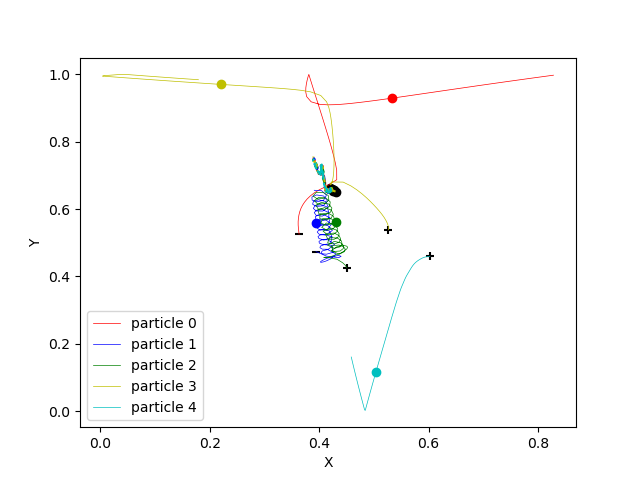

In [11]:
plot_trajectory(data, n_particles)

tensor(0.)
tensor(0.)
tensor(0.)
tensor(0.)
tensor(1.)


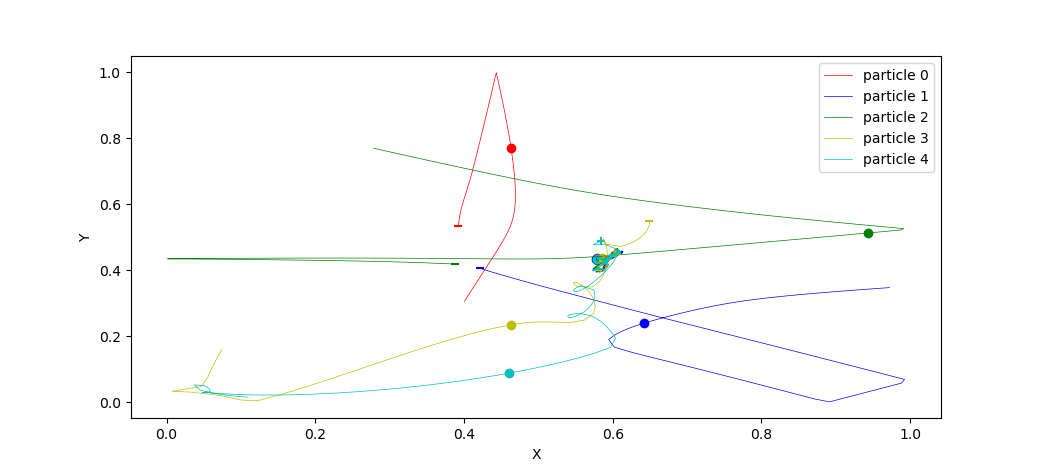

In [33]:
td = random.choice(list(test_dataloader))
data = td['data'].to(device).float()
time = data.size(1)
hf_time = int(time*encoder_ratio)

model.eval()
val_batch_loss = []
with torch.no_grad():
        test_in = data[:, :hf_time, :, :].clone() # shape: (batch, s1, n_particles, n_features)
        test_label = data[:, hf_time:, :, :].clone() # shape: (batch, s2, n_particles, n_features)
        n_time_steps = data.size(1)-hf_time
        out = test_step(model, only_encoder, test_in, n_time_steps, train_opt, model_opt, device)    
                      
out = out.squeeze(0).cpu()   
charge = out[:,:,0] # shape: (time, n_particles, 1)
location = out[:,:,1:3] # shape: (time, n_particles, 2)
velocity = out[:,:,3:] # shape: (time, n_particles, 2)
plot_trajectory(data, n_particles)